In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [15]:
# our data, built right here
reviews = [
    "the movie was great",
    "i hated this movie",
    "the story was amazing",
    "the acting was excellent",
    "this movie was fantastic",
    "i really hated this",
    "the movie felt boring",
    "the story was interesting",
    "i hated the ending",
    "characters were very good"
]

# give every unique word an integer id
words = sorted({w for r in reviews for w in r.split()})
stoi = {w: i for i, w in enumerate(words)}   # string -> id

def encode(text):
    return torch.tensor([stoi[w] for w in text.split()])

print(encode("the movie was great"))   # tensor([...ids...])


tensor([16, 13, 19,  9])


In [16]:

import torch.nn as nn
# one trainable vector per word (here: 4 numbers each)
embedding = nn.Embedding(num_embeddings=len(stoi), embedding_dim=4)

ids = encode("the movie was great")   # shape (4,)  -> 4 words
vectors = embedding(ids)              # shape (4, 4) -> a vector per word

print(vectors.shape)                 # torch.Size([4, 4])



sentence_vector = vectors.mean(dim=0)   # average the rows
print(sentence_vector.shape)          # torch.Size([4])

torch.Size([4, 4])
torch.Size([4])


In [17]:
vectors

tensor([[ 0.5199,  0.4934,  1.0328, -0.3037],
        [-0.2511,  0.6325, -2.4387, -1.6098],
        [-0.9796,  1.4020, -0.1093, -0.4238],
        [-1.0438, -1.4334,  0.2427,  0.9943]], grad_fn=<EmbeddingBackward0>)

In [18]:
stoi

{'acting': 0,
 'amazing': 1,
 'boring': 2,
 'characters': 3,
 'ending': 4,
 'excellent': 5,
 'fantastic': 6,
 'felt': 7,
 'good': 8,
 'great': 9,
 'hated': 10,
 'i': 11,
 'interesting': 12,
 'movie': 13,
 'really': 14,
 'story': 15,
 'the': 16,
 'this': 17,
 'very': 18,
 'was': 19,
 'were': 20}

In [19]:
sentence_vector = vectors.mean(dim = 0)
print(sentence_vector)

tensor([-0.4387,  0.2736, -0.3181, -0.3358], grad_fn=<MeanBackward1>)


In [20]:
class SentimentNet(nn.Module):
    def __init__(self,vocab_size, dim = 8):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, dim)
        self.fc  = nn.Linear(dim, 2)

    def forward(self, ids):
        pooled = self.emb(ids).mean(dim=0, keepdim=True)
        return self.fc(pooled)
        

In [21]:
train = [
    ["the movie was great", 1],
    ["i hated this movie", 0],
    ["the story was amazing", 1],
    ["the acting was excellent", 1],
    ["this movie was fantastic", 1],
    ["i really hated this", 0],
    ["the movie felt boring", 0],
    ["the story was interesting", 1],
    ["i hated the ending", 0],
    ["characters were very good", 1]
]

In [42]:
model  = SentimentNet(len(stoi), dim = 8)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.05)

loss_tensor = []
for epoch in range (120):
    losses = [loss_fn(model(encode(t)), torch.tensor([y]))
               for t , y in train]
    loss = torch.stack(losses).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_tensor.append(loss)
    print(f"At epoch:{epoch} loss:{loss}")


At epoch:0 loss:0.6982409954071045
At epoch:1 loss:0.5726667046546936
At epoch:2 loss:0.47807854413986206
At epoch:3 loss:0.40465372800827026
At epoch:4 loss:0.3418905735015869
At epoch:5 loss:0.2817384600639343
At epoch:6 loss:0.2227114737033844
At epoch:7 loss:0.16751544177532196
At epoch:8 loss:0.11975421756505966
At epoch:9 loss:0.0819149762392044
At epoch:10 loss:0.05445896461606026
At epoch:11 loss:0.03598285838961601
At epoch:12 loss:0.02416655793786049
At epoch:13 loss:0.016758527606725693
At epoch:14 loss:0.012067411094903946
At epoch:15 loss:0.008998583070933819
At epoch:16 loss:0.006900948937982321
At epoch:17 loss:0.005402424838393927
At epoch:18 loss:0.004291613586246967
At epoch:19 loss:0.0034455289132893085
At epoch:20 loss:0.0027892212383449078
At epoch:21 loss:0.0022741544526070356
At epoch:22 loss:0.001866752514615655
At epoch:23 loss:0.0015427798498421907
At epoch:24 loss:0.0012840044219046831
At epoch:25 loss:0.0010764182079583406
At epoch:26 loss:0.0009092221152968

In [43]:
from matplotlib import pyplot as  plt
import numpy as np
loss_numpy = []

for i in loss_tensor:
    loss_numpy.append(i.detach().numpy())

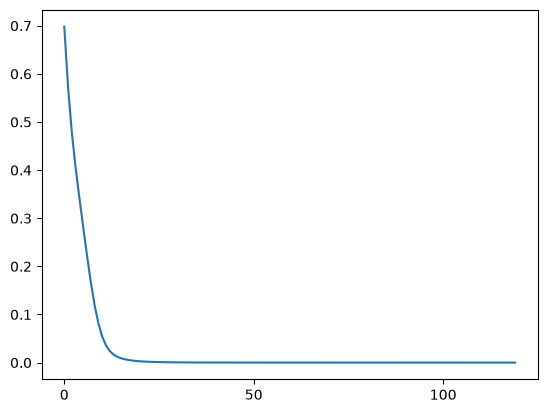

In [48]:
plt.plot(loss_numpy)
plt.xticks(np.arange(0, 120, 50))
plt.show()